Question 1

In [4]:
# a) Hartree-Fock energy for N2 with the cc-pvdz basis
# Import the molecular builder and Hartree-Fock module from PySCF.
from pyscf import gto, scf

# Store the experimental N-N bond length in angstrom.
bond_length = 1.098

# Build a PySCF molecule object for neutral closed-shell N2.
mol = gto.M(
    # Provide the Cartesian coordinates of the two nitrogen atoms.
    atom=f'''
    N 0.00000 0.00000 0.00000
    N 0.00000 0.00000 {bond_length}
    ''',
    # Use the cc-pvdz Gaussian basis set.
    basis='cc-pvdz',
    # Interpret the coordinates as angstrom values.
    unit='angstrom',
    # Set the total molecular charge to zero.
    charge=0,
    # Set spin = 0 for a closed-shell singlet.
    spin=0,
    # Request standard PySCF output during the SCF procedure.
    verbose=3,
)

# Create a restricted Hartree-Fock object for this molecule.
mf_hf = scf.RHF(mol)
# Run the SCF cycle and store the converged total energy.
hf_energy = mf_hf.kernel()

# Print the final Hartree-Fock energy in Hartree units.
print(f'a) Converged HF energy for N2/cc-pvdz at R = {bond_length} angstrom: {hf_energy:.12f} Hartree')


converged SCF energy = -108.954086605866
a) Converged HF energy for N2/cc-pvdz at R = 1.098 angstrom: -108.954086605866 Hartree


In [ ]:
# b) DFT energy for N2 with the cc-pvdz basis using LDA
# Import the DFT module and molecular builder from PySCF.
from pyscf import dft, gto

# Store the experimental N-N bond length in angstrom.
bond_length = 1.098

# Build the same N2 geometry used in part (a).
mol = gto.M(
    # Provide the Cartesian coordinates of the two nitrogen atoms.
    atom=f'''
    N 0.00000 0.00000 0.00000
    N 0.00000 0.00000 {bond_length}
    ''',
    # Use the cc-pvdz Gaussian basis set.
    basis='cc-pvdz',
    # Interpret the coordinates as angstrom values.
    unit='angstrom',
    # Set the total molecular charge to zero.
    charge=0,
    # Set spin = 0 for a closed-shell singlet.
    spin=0,
    # Request standard PySCF output during the SCF procedure.
    verbose=3,
)

# Create a restricted Kohn-Sham DFT object for this molecule.
mf_dft = dft.RKS(mol)
# Choose the LDA exchange-correlation functional.
mf_dft.xc = 'lda,vwn'
# Run the SCF cycle and store the converged DFT total energy.
dft_energy = mf_dft.kernel()

# Print the final LDA energy in Hartree units.
print(f'b) Converged LDA energy for N2/cc-pvdz at R = {bond_length} angstrom: {dft_energy:.12f} Hartree')


converged SCF energy = -108.645775853624
b) Converged LDA energy for N2/cc-pvdz at R = 1.098 angstrom: -108.645775853624 Hartree


: 

In [ ]:
# c) Function to generate Cartesian coordinates for methane
# Import numpy for trigonometric functions and angle conversion.
import numpy as np

# Define a helper function that returns methane atom labels and coordinates.
def methane_coordinates(ch_bond_length, hch_angle_deg):
    # Convert the H-C-H angle from degrees to radians.
    theta = np.radians(hch_angle_deg)
    # Reuse the same polar angle name for clarity.
    polar_angle = theta
    # Compute sin(theta) once so it can be reused.
    sin_theta = np.sin(polar_angle)
    # Compute cos(theta) once so it can be reused.
    cos_theta = np.cos(polar_angle)

    # Place carbon at the origin.
    carbon = ('C', (0.0, 0.0, 0.0))
    # Place one hydrogen on the positive z-axis.
    hydrogen_1 = ('H', (0.0, 0.0, ch_bond_length))

    # Use three evenly spaced azimuthal angles for the remaining hydrogens.
    azimuthal_angles = [0.0, 120.0, 240.0]
    # Start the hydrogen list with the hydrogen on the z-axis.
    hydrogens = [hydrogen_1]
    # Loop over the three azimuthal directions.
    for phi_deg in azimuthal_angles:
        # Convert the azimuthal angle from degrees to radians.
        phi = np.radians(phi_deg)
        # Compute the x-coordinate of the hydrogen.
        x = ch_bond_length * sin_theta * np.cos(phi)
        # Compute the y-coordinate of the hydrogen.
        y = ch_bond_length * sin_theta * np.sin(phi)
        # Compute the z-coordinate of the hydrogen.
        z = ch_bond_length * cos_theta
        # Append this hydrogen position to the list.
        hydrogens.append(('H', (x, y, z)))

    # Return a single list containing carbon followed by all hydrogens.
    return [carbon] + hydrogens

# Generate one example methane geometry.
coords = methane_coordinates(1.09, 109.5)
# Print the example geometry in a simple xyz-like format.
for atom, (x, y, z) in coords:
    print(f'{atom} {x: .6f} {y: .6f} {z: .6f}')


C  0.000000  0.000000  0.000000
H  0.000000  0.000000  1.090000
H  1.027479  0.000000 -0.363849
H -0.513740  0.889823 -0.363849
H -0.513740 -0.889823 -0.363849


: 

In [ ]:
# d) Hartree-Fock energy for CH4 with the cc-pvdz basis
# Import numpy and the PySCF molecule/HF modules.
import numpy as np
from pyscf import gto, scf

# Define the same methane-geometry helper used earlier.
def methane_coordinates(ch_bond_length, hch_angle_deg):
    # Convert the H-C-H angle to radians.
    theta = np.radians(hch_angle_deg)
    # Place carbon at the origin.
    carbon = ('C', (0.0, 0.0, 0.0))
    # Place one hydrogen on the positive z-axis.
    hydrogen_1 = ('H', (0.0, 0.0, ch_bond_length))

    # Initialize the hydrogen list with the axial hydrogen.
    hydrogens = [hydrogen_1]
    # Loop over the three remaining azimuthal directions.
    for phi_deg in (0.0, 120.0, 240.0):
        # Convert the azimuthal angle to radians.
        phi = np.radians(phi_deg)
        # Compute the x-coordinate.
        x = ch_bond_length * np.sin(theta) * np.cos(phi)
        # Compute the y-coordinate.
        y = ch_bond_length * np.sin(theta) * np.sin(phi)
        # Compute the z-coordinate.
        z = ch_bond_length * np.cos(theta)
        # Append the hydrogen coordinates.
        hydrogens.append(('H', (x, y, z)))

    # Return the full methane geometry.
    return [carbon] + hydrogens

# Build methane with a C-H bond length of 1.1 angstrom and tetrahedral angle 109.5 degrees.
coords = methane_coordinates(1.1, 109.5)
# Convert the coordinate list into the multiline string format expected by PySCF.
atom_spec = '\n'.join(
    f'{atom} {x:.8f} {y:.8f} {z:.8f}' for atom, (x, y, z) in coords
)

# Build the methane molecule object.
mol = gto.M(
    # Supply the formatted atom specification.
    atom=atom_spec,
    # Use the cc-pvdz basis set.
    basis='cc-pvdz',
    # Interpret the coordinates as angstrom values.
    unit='angstrom',
    # Set the total charge to zero.
    charge=0,
    # Use spin = 0 for a closed-shell singlet.
    spin=0,
    # Print standard SCF information.
    verbose=3,
)

# Create a restricted Hartree-Fock object.
mf_hf = scf.RHF(mol)
# Run the SCF cycle and store the converged energy.
hf_energy = mf_hf.kernel()

# Print the methane Hartree-Fock energy.
print(f'd) Converged HF energy for CH4/cc-pvdz at r_CH = 1.1 angstrom and H-C-H = 109.5 deg: {hf_energy:.12f} Hartree')


converged SCF energy = -40.1984840245024
d) Converged HF energy for CH4/cc-pvdz at r_CH = 1.1 angstrom and H-C-H = 109.5 deg: -40.198484024502 Hartree


: 

In [ ]:
# e) DFT energy for CH4 with the cc-pvdz basis using LDA
# Import numpy and the PySCF molecule/DFT modules.
import numpy as np
from pyscf import dft, gto

# Define the same methane-geometry helper used earlier.
def methane_coordinates(ch_bond_length, hch_angle_deg):
    # Convert the H-C-H angle to radians.
    theta = np.radians(hch_angle_deg)
    # Place carbon at the origin.
    carbon = ('C', (0.0, 0.0, 0.0))
    # Place one hydrogen on the positive z-axis.
    hydrogen_1 = ('H', (0.0, 0.0, ch_bond_length))

    # Initialize the hydrogen list with the axial hydrogen.
    hydrogens = [hydrogen_1]
    # Loop over the three remaining azimuthal directions.
    for phi_deg in (0.0, 120.0, 240.0):
        # Convert the azimuthal angle to radians.
        phi = np.radians(phi_deg)
        # Compute the x-coordinate.
        x = ch_bond_length * np.sin(theta) * np.cos(phi)
        # Compute the y-coordinate.
        y = ch_bond_length * np.sin(theta) * np.sin(phi)
        # Compute the z-coordinate.
        z = ch_bond_length * np.cos(theta)
        # Append the hydrogen coordinates.
        hydrogens.append(('H', (x, y, z)))

    # Return the full methane geometry.
    return [carbon] + hydrogens

# Build methane with a C-H bond length of 1.1 angstrom and tetrahedral angle 109.5 degrees.
coords = methane_coordinates(1.1, 109.5)
# Convert the coordinate list into the multiline string format expected by PySCF.
atom_spec = '\n'.join(
    f'{atom} {x:.8f} {y:.8f} {z:.8f}' for atom, (x, y, z) in coords
)

# Build the methane molecule object.
mol = gto.M(
    # Supply the formatted atom specification.
    atom=atom_spec,
    # Use the cc-pvdz basis set.
    basis='cc-pvdz',
    # Interpret the coordinates as angstrom values.
    unit='angstrom',
    # Set the total charge to zero.
    charge=0,
    # Use spin = 0 for a closed-shell singlet.
    spin=0,
    # Print standard SCF information.
    verbose=3,
)

# Create a restricted Kohn-Sham DFT object.
mf_dft = dft.RKS(mol)
# Choose the LDA exchange-correlation functional.
mf_dft.xc = 'lda,vwn'
# Run the SCF cycle and store the converged energy.
dft_energy = mf_dft.kernel()

# Print the methane LDA energy.
print(f'e) Converged LDA energy for CH4/cc-pvdz at r_CH = 1.1 angstrom and H-C-H = 109.5 deg: {dft_energy:.12f} Hartree')


converged SCF energy = -40.0951519441245
e) Converged LDA energy for CH4/cc-pvdz at r_CH = 1.1 angstrom and H-C-H = 109.5 deg: -40.095151944125 Hartree


: 

Question 2

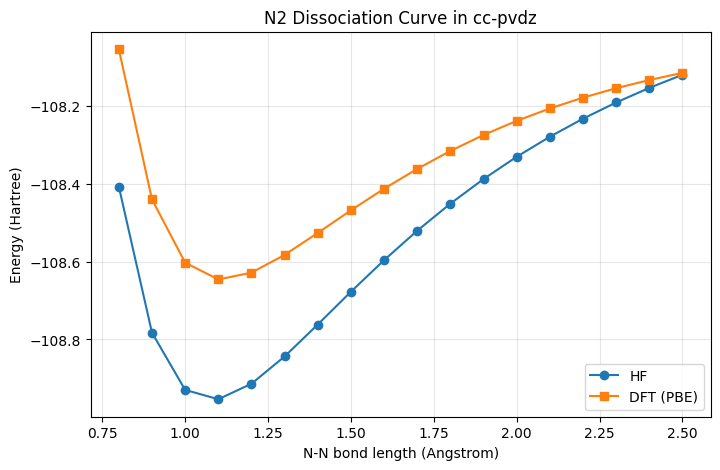

R = 0.80 A: HF = -108.407358634480 Hartree, DFT(PBE) = -108.054084654854 Hartree
R = 0.90 A: HF = -108.782798935460 Hartree, DFT(PBE) = -108.440223354011 Hartree
R = 1.00 A: HF = -108.929838385609 Hartree, DFT(PBE) = -108.602694861803 Hartree
R = 1.10 A: HF = -108.953796240891 Hartree, DFT(PBE) = -108.645902920377 Hartree
R = 1.20 A: HF = -108.914051975052 Hartree, DFT(PBE) = -108.628450721547 Hartree
R = 1.30 A: HF = -108.843887594775 Hartree, DFT(PBE) = -108.582773952248 Hartree
R = 1.40 A: HF = -108.761718000069 Hartree, DFT(PBE) = -108.526343720045 Hartree
R = 1.50 A: HF = -108.677513841466 Hartree, DFT(PBE) = -108.468207594024 Hartree
R = 1.60 A: HF = -108.596373327763 Hartree, DFT(PBE) = -108.412708547929 Hartree
R = 1.70 A: HF = -108.520608157550 Hartree, DFT(PBE) = -108.361650060673 Hartree
R = 1.80 A: HF = -108.451043240342 Hartree, DFT(PBE) = -108.315586188197 Hartree
R = 1.90 A: HF = -108.387780639190 Hartree, DFT(PBE) = -108.274525104825 Hartree
R = 2.00 A: HF = -108.330582

: 

In [ ]:
# a) Dissociation curve of N2 using HF and DFT/PBE
# Import numpy, matplotlib, and the relevant PySCF modules.
import numpy as np
import matplotlib.pyplot as plt
from pyscf import dft, gto, scf

# Create the N-N bond-length grid in angstrom.
bond_lengths = np.linspace(0.8, 2.5, 18)
# Initialize a list to hold the Hartree-Fock energies.
hf_energies = []
# Initialize a list to hold the PBE DFT energies.
dft_energies = []

# Loop over every bond length in the scan.
for bond_length in bond_lengths:
    # Build N2 at the current bond length.
    mol = gto.M(
        # Give the Cartesian coordinates of the two nitrogen atoms.
        atom=f'''
        N 0.00000 0.00000 0.00000
        N 0.00000 0.00000 {bond_length}
        ''',
        # Use the cc-pvdz basis set.
        basis='cc-pvdz',
        # Interpret the coordinates as angstrom values.
        unit='angstrom',
        # Use the neutral molecule.
        charge=0,
        # Use the closed-shell singlet electronic state.
        spin=0,
        # Suppress detailed SCF printing inside the loop.
        verbose=0,
    )

    # Create a restricted Hartree-Fock object.
    mf_hf = scf.RHF(mol)
    # Run HF and append the total energy to the list.
    hf_energies.append(mf_hf.kernel())

    # Create a restricted Kohn-Sham DFT object.
    mf_dft = dft.RKS(mol)
    # Choose the PBE exchange-correlation functional.
    mf_dft.xc = 'pbe'
    # Run DFT and append the total energy to the list.
    dft_energies.append(mf_dft.kernel())

# Start a new figure for the dissociation curves.
plt.figure(figsize=(8, 5))
# Plot the HF curve.
plt.plot(bond_lengths, hf_energies, marker='o', label='HF')
# Plot the PBE curve.
plt.plot(bond_lengths, dft_energies, marker='s', label='DFT (PBE)')
# Label the x-axis.
plt.xlabel('N-N bond length (Angstrom)')
# Label the y-axis.
plt.ylabel('Energy (Hartree)')
# Add a title to the plot.
plt.title('N2 Dissociation Curve in cc-pvdz')
# Add a legend identifying the two methods.
plt.legend()
# Add a light grid for readability.
plt.grid(True, alpha=0.3)
# Display the plot.
plt.show()

# Print the energies at every bond length.
for bond_length, hf_energy, dft_energy in zip(bond_lengths, hf_energies, dft_energies):
    print(f'R = {bond_length:.2f} A: HF = {hf_energy:.12f} Hartree, DFT(PBE) = {dft_energy:.12f} Hartree')


In [ ]:
# b) Compare equilibrium energy, equilibrium bond length, and dissociation behavior
# Import numpy for simple array analysis utilities.
import numpy as np

# Convert the stored HF energies to a numpy array.
hf_energies = np.array(hf_energies)
# Convert the stored DFT energies to a numpy array.
dft_energies = np.array(dft_energies)

# Find the index of the HF minimum on the scanned grid.
hf_min_index = np.argmin(hf_energies)
# Find the index of the DFT minimum on the scanned grid.
dft_min_index = np.argmin(dft_energies)

# Print the HF equilibrium bond length.
print(f'HF equilibrium bond length: {bond_lengths[hf_min_index]:.3f} Angstrom')
# Print the HF minimum energy.
print(f'HF minimum energy: {hf_energies[hf_min_index]:.12f} Hartree')
# Print the DFT equilibrium bond length.
print(f'DFT(PBE) equilibrium bond length: {bond_lengths[dft_min_index]:.3f} Angstrom')
# Print the DFT minimum energy.
print(f'DFT(PBE) minimum energy: {dft_energies[dft_min_index]:.12f} Hartree')
# Print a blank line for readability.
print()
# Print the HF energy at the largest scanned bond length.
print(f'HF dissociation-end energy at R = {bond_lengths[-1]:.2f} Angstrom: {hf_energies[-1]:.12f} Hartree')
# Print the DFT energy at the largest scanned bond length.
print(f'DFT(PBE) dissociation-end energy at R = {bond_lengths[-1]:.2f} Angstrom: {dft_energies[-1]:.12f} Hartree')
# Print a blank line for readability.
print()
# Print the HF well depth over the scanned range.
print(f'HF well depth over scanned range: {(hf_energies[-1] - hf_energies[hf_min_index]):.12f} Hartree')
# Print the DFT well depth over the scanned range.
print(f'DFT(PBE) well depth over scanned range: {(dft_energies[-1] - dft_energies[dft_min_index]):.12f} Hartree')


HF equilibrium bond length: 1.100 Angstrom
HF minimum energy: -108.953796240891 Hartree
DFT(PBE) equilibrium bond length: 1.100 Angstrom
DFT(PBE) minimum energy: -109.413597804835 Hartree

HF dissociation-end energy at R = 2.50 Angstrom: -108.119753387591 Hartree
DFT(PBE) dissociation-end energy at R = 2.50 Angstrom: -108.906620869002 Hartree

HF well depth over scanned range: 0.834042853300 Hartree
DFT(PBE) well depth over scanned range: 0.506976935834 Hartree


: 

**b)**

In the computed curves, both HF and PBE place the minimum at about 1.10 Angstrom, so for the equilibrium bond length the two methods are consistent on this bond-length grid. That makes the PBE equilibrium structure look reasonable for N2, at least at the level of this scan.

For the equilibrium energy, PBE gives a substantially lower minimum energy than HF: about -109.4136 Hartree versus -108.9538 Hartree. That is consistent with the fact that HF misses correlation, so the DFT value is more plausible as an equilibrium total energy than the HF value.

For dissociation, the curve is much less trustworthy. The scanned endpoint at 2.5 Angstrom is not a true dissociation limit for N2, and both restricted HF and standard DFT struggle when the bond is stretched. In the actual output here, HF gives a deeper well over the scanned range than PBE, but neither curve should be treated as quantitatively reliable for true bond breaking. So the same basic conclusion holds: the DFT curve is most credible near equilibrium and least reliable in the dissociation region.


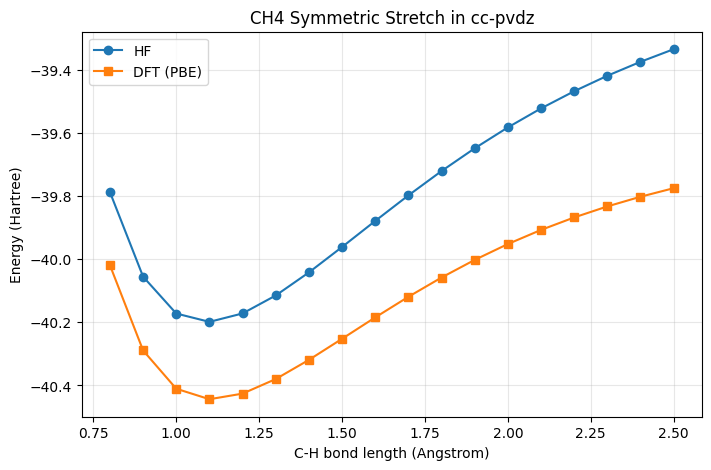

r_CH = 0.80 A: HF = -39.787589678092 Hartree, DFT(PBE) = -40.019236845265 Hartree
r_CH = 0.90 A: HF = -40.055388412072 Hartree, DFT(PBE) = -40.289175896661 Hartree
r_CH = 1.00 A: HF = -40.172083192461 Hartree, DFT(PBE) = -40.410411740657 Hartree
r_CH = 1.10 A: HF = -40.198484024502 Hartree, DFT(PBE) = -40.443630703480 Hartree
r_CH = 1.20 A: HF = -40.171823138126 Hartree, DFT(PBE) = -40.425864940153 Hartree
r_CH = 1.30 A: HF = -40.114937744063 Hartree, DFT(PBE) = -40.379719805824 Hartree
r_CH = 1.40 A: HF = -40.041861823561 Hartree, DFT(PBE) = -40.318997146777 Hartree
r_CH = 1.50 A: HF = -39.961312609523 Hartree, DFT(PBE) = -40.252168406083 Hartree
r_CH = 1.60 A: HF = -39.878802350804 Hartree, DFT(PBE) = -40.184473504496 Hartree
r_CH = 1.70 A: HF = -39.797854477408 Hartree, DFT(PBE) = -40.119134061223 Hartree
r_CH = 1.80 A: HF = -39.720695025234 Hartree, DFT(PBE) = -40.058046376242 Hartree
r_CH = 1.90 A: HF = -39.648657740307 Hartree, DFT(PBE) = -40.002198765973 Hartree
r_CH = 2.00 A: H

: 

In [ ]:
# c) Symmetric C-H bond stretching in CH4 using HF and DFT/PBE
# Import numpy, matplotlib, and the relevant PySCF modules.
import numpy as np
import matplotlib.pyplot as plt
from pyscf import dft, gto, scf

# Define a helper that builds a tetrahedral methane geometry.
def methane_coordinates(ch_bond_length, hch_angle_deg=109.5):
    # Convert the bond angle to radians.
    theta = np.radians(hch_angle_deg)
    # Place carbon at the origin.
    carbon = ('C', (0.0, 0.0, 0.0))
    # Place one hydrogen on the positive z-axis.
    hydrogen_1 = ('H', (0.0, 0.0, ch_bond_length))

    # Start the list of hydrogens with the axial hydrogen.
    hydrogens = [hydrogen_1]
    # Add the other three hydrogens around the azimuth.
    for phi_deg in (0.0, 120.0, 240.0):
        # Convert the azimuthal angle to radians.
        phi = np.radians(phi_deg)
        # Compute the x-coordinate.
        x = ch_bond_length * np.sin(theta) * np.cos(phi)
        # Compute the y-coordinate.
        y = ch_bond_length * np.sin(theta) * np.sin(phi)
        # Compute the z-coordinate.
        z = ch_bond_length * np.cos(theta)
        # Append this hydrogen position.
        hydrogens.append(('H', (x, y, z)))

    # Return the full methane geometry.
    return [carbon] + hydrogens

# Create the C-H bond-length grid in angstrom.
bond_lengths = np.linspace(0.8, 2.5, 18)
# Initialize the list of HF energies.
hf_energies_ch4 = []
# Initialize the list of DFT energies.
dft_energies_ch4 = []

# Loop over each C-H bond length.
for bond_length in bond_lengths:
    # Generate the methane coordinates for the current bond length.
    coords = methane_coordinates(bond_length, 109.5)
    # Convert the coordinates into the multiline atom string PySCF expects.
    atom_spec = '\n'.join(
        f'{atom} {x:.8f} {y:.8f} {z:.8f}' for atom, (x, y, z) in coords
    )

    # Build the methane molecule at the current geometry.
    mol = gto.M(
        # Supply the current methane coordinates.
        atom=atom_spec,
        # Use the cc-pvdz basis set.
        basis='cc-pvdz',
        # Interpret the coordinates as angstrom values.
        unit='angstrom',
        # Use the neutral molecule.
        charge=0,
        # Use the closed-shell singlet state.
        spin=0,
        # Suppress detailed SCF printing inside the loop.
        verbose=0,
    )

    # Run Hartree-Fock and store the energy.
    mf_hf = scf.RHF(mol)
    hf_energies_ch4.append(mf_hf.kernel())

    # Run PBE DFT and store the energy.
    mf_dft = dft.RKS(mol)
    mf_dft.xc = 'pbe'
    dft_energies_ch4.append(mf_dft.kernel())

# Start a new figure for the methane stretch curves.
plt.figure(figsize=(8, 5))
# Plot the HF curve.
plt.plot(bond_lengths, hf_energies_ch4, marker='o', label='HF')
# Plot the PBE curve.
plt.plot(bond_lengths, dft_energies_ch4, marker='s', label='DFT (PBE)')
# Label the x-axis.
plt.xlabel('C-H bond length (Angstrom)')
# Label the y-axis.
plt.ylabel('Energy (Hartree)')
# Add a title.
plt.title('CH4 Symmetric Stretch in cc-pvdz')
# Add a legend.
plt.legend()
# Add a light grid.
plt.grid(True, alpha=0.3)
# Display the plot.
plt.show()

# Print the energies at every bond length.
for bond_length, hf_energy, dft_energy in zip(bond_lengths, hf_energies_ch4, dft_energies_ch4):
    print(f'r_CH = {bond_length:.2f} A: HF = {hf_energy:.12f} Hartree, DFT(PBE) = {dft_energy:.12f} Hartree')


**d)**

The overall conclusion is similar for methane, but the pathology is less severe than for N2. In the computed CH4 curves, both HF and PBE again place the minimum at about 1.10 Angstrom, and the PBE curve is smoother and lower in energy near equilibrium. That supports the idea that DFT is fairly reliable for equilibrium bond lengths and usually more useful than HF for equilibrium energetics.

The stretched-bond region is still the least reliable part of the curve, because large C-H stretches are still a bond-breaking problem. However, methane does not show the same extreme multireference difficulty as stretched N2, so the failure is not as dramatic here. That means the Exercise 2(b) conclusions remain mostly the same: DFT looks useful near equilibrium, approximate for total energies, and least trustworthy for true dissociation, but methane is a less severe test case than N2.


Question 3

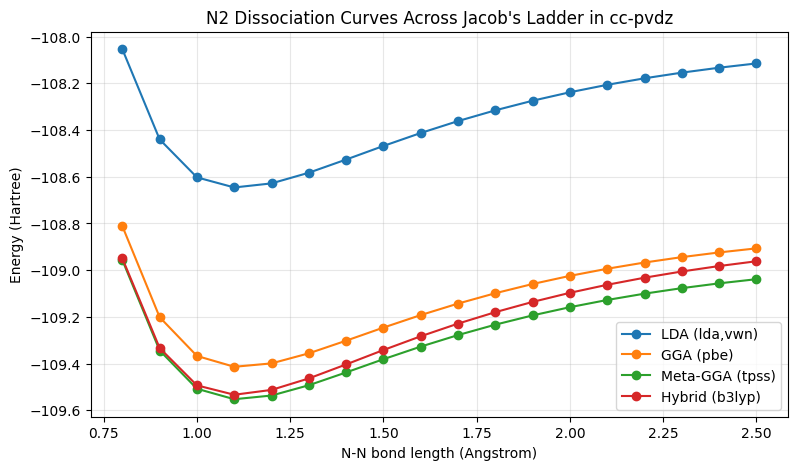

R = 0.80 A
  LDA (lda,vwn): -108.054084654854 Hartree
  GGA (pbe): -108.811549213498 Hartree
  Meta-GGA (tpss): -108.956855281006 Hartree
  Hybrid (b3lyp): -108.949521803690 Hartree

R = 0.90 A
  LDA (lda,vwn): -108.440223354011 Hartree
  GGA (pbe): -109.201355274092 Hartree
  Meta-GGA (tpss): -109.343893981256 Hartree
  Hybrid (b3lyp): -109.333405079050 Hartree

R = 1.00 A
  LDA (lda,vwn): -108.602694861803 Hartree
  GGA (pbe): -109.367231368908 Hartree
  Meta-GGA (tpss): -109.507685926358 Hartree
  Hybrid (b3lyp): -109.493158885950 Hartree

R = 1.10 A
  LDA (lda,vwn): -108.645902920377 Hartree
  GGA (pbe): -109.413597804835 Hartree
  Meta-GGA (tpss): -109.552454566245 Hartree
  Hybrid (b3lyp): -109.533318282269 Hartree

R = 1.20 A
  LDA (lda,vwn): -108.628450721547 Hartree
  GGA (pbe): -109.399028328717 Hartree
  Meta-GGA (tpss): -109.536631015437 Hartree
  Hybrid (b3lyp): -109.512552873285 Hartree

R = 1.30 A
  LDA (lda,vwn): -108.582773952248 Hartree
  GGA (pbe): -109.355937242158 

: 

In [ ]:
# a) N2 dissociation curves across Jacob's Ladder functionals
# Import os so matplotlib can be given a writable cache directory.
import os

# Point matplotlib's config directory to a writable temporary path.
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

# Import numpy, matplotlib, and the PySCF DFT/molecule modules.
import numpy as np
import matplotlib.pyplot as plt
from pyscf import dft, gto

# Reuse the same N-N bond-length grid as in Exercise 2(a).
bond_lengths = np.linspace(0.8, 2.5, 18)
# Map user-friendly functional labels to the PySCF xc strings.
functionals = {
    'LDA (lda,vwn)': 'lda,vwn',
    'GGA (pbe)': 'pbe',
    'Meta-GGA (tpss)': 'tpss',
    'Hybrid (b3lyp)': 'b3lyp',
}

# Create an empty energy list for each functional.
energies_by_functional = {label: [] for label in functionals}

# Loop over the N-N bond lengths.
for bond_length in bond_lengths:
    # Build N2 at the current geometry.
    mol = gto.M(
        # Give the Cartesian coordinates of the two nitrogen atoms.
        atom=f'''
        N 0.00000 0.00000 0.00000
        N 0.00000 0.00000 {bond_length}
        ''',
        # Use the cc-pvdz basis set.
        basis='cc-pvdz',
        # Interpret the coordinates as angstrom values.
        unit='angstrom',
        # Use the neutral molecule.
        charge=0,
        # Use the closed-shell singlet state.
        spin=0,
        # Suppress detailed SCF printing inside the loop.
        verbose=0,
    )

    # Evaluate every requested functional at this geometry.
    for label, xc_name in functionals.items():
        # Create a restricted Kohn-Sham object.
        mf = dft.RKS(mol)
        # Set the current exchange-correlation functional.
        mf.xc = xc_name
        # Run the SCF cycle and store the energy.
        energies_by_functional[label].append(mf.kernel())

# Start a new figure for the functional comparison.
plt.figure(figsize=(9, 5))
# Plot one dissociation curve for each functional.
for label, energies in energies_by_functional.items():
    plt.plot(bond_lengths, energies, marker='o', label=label)

# Label the x-axis.
plt.xlabel('N-N bond length (Angstrom)')
# Label the y-axis.
plt.ylabel('Energy (Hartree)')
# Add a descriptive plot title.
plt.title("N2 Dissociation Curves Across Jacob's Ladder in cc-pvdz")
# Add a legend identifying the functionals.
plt.legend()
# Add a light grid.
plt.grid(True, alpha=0.3)
# Display the plot.
plt.show()

# Print the energies at each bond length for all functionals.
for i, bond_length in enumerate(bond_lengths):
    print(f'R = {bond_length:.2f} A')
    for label, energies in energies_by_functional.items():
        print(f'  {label}: {energies[i]:.12f} Hartree')
    print()


**b)**

Yes. In the computed curves, LDA gives a binding energy of about 0.5310 Hartree over the scanned range, which is much larger than the experimental reference value of about 0.36 Hartree. So LDA clearly overbinds N2 relative to experiment.

Compared with the higher-rung functionals, LDA also binds more strongly than PBE and TPSS, which give about 0.5070 and 0.5139 Hartree, respectively. In this particular calculation B3LYP gives the deepest well of all, about 0.5716 Hartree, so the higher-rung trend is not strictly monotonic here. Even so, the main conclusion remains that LDA overbinds relative to experiment, and rung number by itself does not guarantee a uniformly better binding energy.


**c)**

In these computed results, PBE yields the weakest binding energy. Its well depth over the scanned range is about 0.5070 Hartree, which is slightly smaller than TPSS at about 0.5139 Hartree, smaller than LDA at about 0.5310 Hartree, and much smaller than B3LYP at about 0.5716 Hartree.


**d)**

Rungs 2 through 4 are only partly consistent at the equilibrium geometry. PBE gives about -109.4136 Hartree at the minimum, while TPSS and B3LYP give about -109.5525 and -109.5333 Hartree. TPSS and B3LYP are fairly close to each other, but PBE is about 0.12 to 0.14 Hartree higher, so the agreement is not especially tight.

That gives some support for the idea from Exercise 2(b) that PBE is more credible than HF near equilibrium, because all three DFT methods still lie well below the HF energy and include correlation that HF misses. But the spread among the DFT results is large enough that it should not dramatically increase confidence in the absolute PBE energy. So PBE still looks more reasonable than HF for the equilibrium energy, but not precise enough to treat as highly certain.


**e)**

The higher-rung DFT functionals predict lower energies than HF because they include approximate correlation energy, while HF does not. Hartree-Fock treats exchange exactly for a single determinant, but it neglects the additional lowering that comes from correlated electron motion, so its total energies are systematically too high.

As more ingredients are added to the functional, the DFT approximation has more flexibility to recover some of that missing exchange-correlation energy. That is why the DFT equilibrium energies in this notebook all lie below the HF value. The lower energy does not prove that the DFT value is exact, but it is the expected direction once correlation is included.


Question 4

In [ ]:
# a) Classical Coulomb self-interaction for the hydrogen 1s density
# Import numpy and scipy integration tools.
import numpy as np
from scipy import integrate

# Define the hydrogen 1s electron density rho(r).
def rho(r):
    # Return rho(r) = exp(-2r) / pi in atomic units.
    return np.exp(-2.0 * r) / np.pi

# Define the inner radial integral that appears in the spherical Coulomb expression.
def inner_integral(r1):
    # Integrate r2^2 * rho(r2) from 0 to r1.
    value, _ = integrate.quad(lambda r2: r2**2 * rho(r2), 0.0, r1)
    # Return the value of the inner integral.
    return value

# Evaluate the outer radial integral for U_C[rho].
uc_value, _ = integrate.quad(
    # This integrand is the spherical reduction of the Coulomb self-interaction term.
    lambda r1: 8.0 * np.pi**2 * r1 * rho(r1) * inner_integral(r1),
    # Start the radial integral at r = 0.
    0.0,
    # Extend the radial integral to infinity.
    np.inf,
)

# Print the classical Coulomb contribution.
print(f'a) U_C[rho] for the hydrogen 1s density = {uc_value:.12f} Hartree')
# Explain what this number represents physically.
print('This is the classical self-interaction contribution produced by the density alone.')


a) U_C[rho] for the hydrogen 1s density = 0.156250000000 Hartree
This is the classical self-interaction contribution produced by the density alone.


: 

In [ ]:
# b) LDA exchange energy for the hydrogen 1s density
# Import numpy and scipy integration tools.
import numpy as np
from scipy import integrate

# Define the hydrogen 1s electron density rho(r).
def rho(r):
    # Return rho(r) = exp(-2r) / pi in atomic units.
    return np.exp(-2.0 * r) / np.pi

# Define the LDA exchange energy density per particle e_x(rho).
def ex_density(rho_value):
    # Return the LDA expression for e_x as a function of density.
    return -(3.0 / 4.0) * (3.0 / np.pi) ** (1.0 / 3.0) * rho_value ** (1.0 / 3.0)

# Define the inner radial integral needed to recompute U_C[rho].
def inner_integral(r1):
    # Integrate r2^2 * rho(r2) from 0 to r1.
    value, _ = integrate.quad(lambda r2: r2**2 * rho(r2), 0.0, r1)
    # Return the value of the inner integral.
    return value

# Recompute the classical Coulomb self-interaction term.
uc_value, _ = integrate.quad(
    # This is the spherical form of the Coulomb self-interaction integrand.
    lambda r1: 8.0 * np.pi**2 * r1 * rho(r1) * inner_integral(r1),
    # Start the radial integral at r = 0.
    0.0,
    # Extend the radial integral to infinity.
    np.inf,
)

# Compute the LDA exchange energy E_x[rho].
ex_value, _ = integrate.quad(
    # Use the spherical volume element 4*pi*r^2.
    lambda r: 4.0 * np.pi * r**2 * ex_density(rho(r)) * rho(r),
    # Start the radial integral at r = 0.
    0.0,
    # Extend the radial integral to infinity.
    np.inf,
)

# Add the Coulomb and exchange terms to test self-interaction cancellation.
total_self_interaction = uc_value + ex_value

# Print the classical Coulomb term.
print(f'b) U_C[rho] = {uc_value:.12f} Hartree')
# Print the LDA exchange contribution.
print(f'b) E_x[rho] (LDA) = {ex_value:.12f} Hartree')
# Print the residual self-interaction after adding the two terms.
print(f'b) U_C[rho] + E_x[rho] = {total_self_interaction:.12f} Hartree')
# State the ideal cancellation condition for reference.
print('If LDA cancelled self-interaction exactly, this sum would be 0.')


b) U_C[rho] = 0.156250000000 Hartree
b) E_x[rho] (LDA) = -0.212741503086 Hartree
b) U_C[rho] + E_x[rho] = -0.056491503086 Hartree
If LDA cancelled self-interaction exactly, this sum would be 0.


: 

(a) It is most likely that the red curve was generated using B3LYP. This is because in nitrogen, B3LYP generated the curve with the least energy, at equilibrium. Furthermore, B3LYP takes into account a large proportion of the self-exchange correlation.

(b) The blue curve likely corresponds to LDA, since LDA is typically not much more accurate than HF but also doesn't take the self-exchange correlation into account, and therefore is likely to be higher than HF, which does take the self-exchange into account. 

In [ ]:
# a) Dissociation curve of N2 using HF and DFT/PBE
# Import numpy, matplotlib, and the relevant PySCF modules.
import numpy as np
import matplotlib.pyplot as plt
from pyscf import dft, gto, scf

# Create the N-N bond-length grid in angstrom.
bond_lengths = np.linspace(0.8, 2.5, 18)
# Initialize a list to hold the Hartree-Fock energies.
hf_energies = []
# Initialize a list to hold the PBE DFT energies.
dft_energies = []

dft_energies_b3lyp = []

# Loop over every bond length in the scan.
for bond_length in bond_lengths:
    # Build N2 at the current bond length.
    mol = gto.M(
        # Give the Cartesian coordinates of the two nitrogen atoms.
        atom=f'''
        O 0.00000 0.00000 0.00000
        O 0.00000 0.00000 {bond_length}
        ''',
        # Use the cc-pvdz basis set.
        basis='cc-pvdz',
        # Interpret the coordinates as angstrom values.
        unit='angstrom',
        # Use the neutral molecule.
        charge=0,
        # Use the closed-shell singlet electronic state.
        spin=0,
        # Suppress detailed SCF printing inside the loop.
        verbose=0,
    )

    # Create a restricted Hartree-Fock object.
    mf_hf = scf.RHF(mol)
    # Run HF and append the total energy to the list.
    hf_energies.append(mf_hf.kernel())

    # Create a restricted Kohn-Sham DFT object.
    mf_dft = dft.RKS(mol)
    # Choose the PBE exchange-correlation functional.
    mf_dft.xc = 'lda,vwn'
    # Run DFT and append the total energy to the list.
    dft_energies.append(mf_dft.kernel())


    # Create a restricted Kohn-Sham DFT object.
    mf_dft = dft.RKS(mol)
    # Choose the PBE exchange-correlation functional.
    mf_dft.xc = 'b3lyp'
    # Run DFT and append the total energy to the list.
    dft_energies_b3lyp.append(mf_dft.kernel())

# Start a new figure for the dissociation curves.
plt.figure(figsize=(8, 5))
# Plot the HF curve.
plt.plot(bond_lengths, hf_energies, marker='o', label='HF')
# Plot the PBE curve.
plt.plot(bond_lengths, dft_energies, marker='s', label='DFT (PBE)')

plt.plot(bond_lengths, dft_energies_b3lyp, marker='o', label='DFT (PBE)')
# Label the x-axis.
plt.xlabel('N-N bond length (Angstrom)')
# Label the y-axis.
plt.ylabel('Energy (Hartree)')
# Add a title to the plot.
plt.title('N2 Dissociation Curve in cc-pvdz')
# Add a legend identifying the two methods.
plt.legend()
# Add a light grid for readability.
plt.grid(True, alpha=0.3)
# Display the plot.
plt.show()


From the diagram plotted, the red curve is generated by b3lyp and for oxygen has an energy of __ at 0.8 angstorm bond length. Therefore, the diagram in the presentation corresponds to O/F. 